# 2. 일반화 성능 (Generalization)

> 노트북 1에서 우리는 1D-CNN으로 **~100%** 정확도를 달성했습니다.
> 하지만 그 100%가 **새로운 조건**에서도 유지될까요?

## STEP 1: 일반화 성능이란?

**일반화(Generalization)**란, 모델이 **학습 때 보지 못한 새로운 데이터**에서도 잘 동작하는 능력을 말합니다.

### 비유

시험 공부를 할 때:
- 기출문제만 달달 외우면 → **같은 문제**는 맞출 수 있음
- 하지만 **새로운 유형의 문제**가 나오면 → 못 품

AI 모델도 마찬가지입니다:
- 학습 데이터와 비슷한 패턴 → 잘 분류함
- 학습 때 **한 번도 보지 못한 조건** → 정확도 급락 가능

### CWRU 데이터로 실험

CWRU 베어링 데이터에는 **같은 결함 종류**이지만 **결함 크기가 다른** 파일이 있습니다:

| 결함 크기 | 설명 |
|-----------|------|
| 007 mil | 작은 결함 (약 0.18mm) |
| 014 mil | 중간 결함 (약 0.36mm) |
| 021 mil | 큰 결함 (약 0.53mm) |

**실험 설계:**
- 학습: 007mil + 014mil (작은/중간 결함)
- 평가: 021mil (큰 결함 — 학습 때 한 번도 못 봄)

이렇게 하면 모델이 **진짜로** 결함 패턴을 이해한 건지, 아니면 특정 크기의 패턴만 외운 건지 확인할 수 있습니다.

In [1]:
%matplotlib inline

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import loadmat
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
import matplotlib.pyplot as plt
import platform
import re
import os

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 재현성을 위한 시드 설정
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# 디바이스 설정
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: mps


## STEP 2: 데이터를 결함 크기별로 나누기

핵심 아이디어:
- **Train (학습)**: 결함 크기 007mil + 014mil 파일 **전체**
- **Test (평가)**: 결함 크기 021mil 파일 **전체** (학습 때 한 번도 보지 못한 크기!)
- **Normal**: 파일이 1개뿐이므로 시간순으로 앞 70% 학습 / 뒤 30% 평가

In [2]:
# 노트북 1과 동일한 헬퍼 함수들
data_dir = 'dataset/'
WINDOW_SIZE = 2048
STEP = 1024

def get_de_signal(filepath):
    """mat 파일에서 DE(Drive End) 진동 신호를 추출"""
    mat = loadmat(filepath)
    filename = os.path.basename(filepath)
    number = re.search(r'(\d+)\.mat$', filename).group(1)
    key = f'X{number}_DE_time'
    return mat[key].flatten()

def sliding_window_fft(signal, window_size=WINDOW_SIZE, step=STEP):
    """윈도우 슬라이딩 + FFT (노트북 1과 동일)"""
    windows = []
    for start in range(0, len(signal) - window_size + 1, step):
        window = signal[start:start + window_size]
        fft_result = np.abs(np.fft.rfft(window))
        windows.append(fft_result)
    return np.array(windows)

# 학습용 파일: 007mil + 014mil
train_files = {
    'IR007_1_110.mat': 1,
    'IR014_1_175.mat': 1,
    'OR007_6_1_136.mat': 2,
    'OR014_6_1_202.mat': 2,
    'B007_1_123.mat': 3,
    'B014_1_190.mat': 3,
}

# 평가용 파일: 021mil (학습 때 한 번도 본 적 없는 결함 크기!)
test_files = {
    'IR021_1_214.mat': 1,
    'OR021_6_1_239.mat': 2,
    'B021_1_227.mat': 3,
}

normal_file = 'Time_Normal_1_098.mat'
class_names = ['Normal', 'Inner Race', 'Outer Race', 'Ball']

print('학습 데이터: 007mil + 014mil (작은/중간 결함)')
print('평가 데이터: 021mil (큰 결함 - 학습 때 처음 보는 조건)')

학습 데이터: 007mil + 014mil (작은/중간 결함)
평가 데이터: 021mil (큰 결함 - 학습 때 처음 보는 조건)


## STEP 3: 전처리 + 데이터 구성

노트북 1에서 배운 올바른 방법(Clean)을 그대로 사용합니다:
1. 원본 신호에 윈도우 슬라이딩 + FFT 적용
2. StandardScaler 정규화 (학습 데이터 기준으로 fit)

In [3]:
# 학습 데이터 생성 (007mil + 014mil 파일 전체 사용)
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

# Normal: 파일 1개이므로 시간순 70/30 분할
normal_signal = get_de_signal(os.path.join(data_dir, normal_file))
split_idx = int(len(normal_signal) * 0.7)
train_fft = sliding_window_fft(normal_signal[:split_idx])
test_fft = sliding_window_fft(normal_signal[split_idx:])
X_train_list.append(train_fft)
y_train_list.extend([0] * len(train_fft))
X_test_list.append(test_fft)
y_test_list.extend([0] * len(test_fft))
print(f'Normal - train: {len(train_fft)}개, test: {len(test_fft)}개')

# 결함 파일: 007+014 → 학습, 021 → 평가
for fname, label in train_files.items():
    signal = get_de_signal(os.path.join(data_dir, fname))
    fft_data = sliding_window_fft(signal)
    X_train_list.append(fft_data)
    y_train_list.extend([label] * len(fft_data))
    print(f'{fname} → 학습: {len(fft_data)}개')

for fname, label in test_files.items():
    signal = get_de_signal(os.path.join(data_dir, fname))
    fft_data = sliding_window_fft(signal)
    X_test_list.append(fft_data)
    y_test_list.extend([label] * len(fft_data))
    print(f'{fname} → 평가: {len(fft_data)}개')

X_train = np.concatenate(X_train_list)
X_test = np.concatenate(X_test_list)
y_train = np.array(y_train_list)
y_test = np.array(y_test_list)

# 정규화: 학습 데이터 기준으로 fit
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'\n전체 학습: {X_train.shape}, 전체 평가: {X_test.shape}')

Normal - train: 329개, test: 140개
IR007_1_110.mat → 학습: 473개
IR014_1_175.mat → 학습: 371개
OR007_6_1_136.mat → 학습: 474개
OR014_6_1_202.mat → 학습: 472개
B007_1_123.mat → 학습: 474개
B014_1_190.mat → 학습: 473개
IR021_1_214.mat → 평가: 472개
OR021_6_1_239.mat → 평가: 476개
B021_1_227.mat → 평가: 474개

전체 학습: (3066, 1025), 전체 평가: (1562, 1025)


In [4]:
# PyTorch 텐서 변환 + DataLoader
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)  # (N, 1, 1025)
y_train_t = torch.LongTensor(y_train)
X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
y_test_t = torch.LongTensor(y_test)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

print(f'학습 텐서: {X_train_t.shape}')
print(f'평가 텐서: {X_test_t.shape}')

학습 텐서: torch.Size([3066, 1, 1025])
평가 텐서: torch.Size([1562, 1, 1025])


## STEP 4: 1D-CNN 학습 (노트북 1과 동일한 모델)

모델 구조는 노트북 1과 완전히 동일합니다. 달라진 건 **데이터 분할 방법**뿐입니다.

```
입력 (1, 1025)
  ↓ Conv1d(1→16, kernel=9) + ReLU + MaxPool(2)
  ↓ Conv1d(16→32, kernel=9) + ReLU + MaxPool(2)
  ↓ Flatten → Linear(64) → Linear(4)
```

In [5]:
# 1D-CNN 모델 (노트북 1과 동일)
class CNN1D(nn.Module):
    def __init__(self, input_size=1025):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=9, padding=4)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=9, padding=4)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * (input_size // 4), 64)
        self.fc2 = nn.Linear(64, 4)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # (B, 16, ~512)
        x = self.pool(self.relu(self.conv2(x)))  # (B, 32, ~256)
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

torch.manual_seed(SEED)
input_size = X_train_t.shape[2]
model = CNN1D(input_size=input_size).to(device)
print(model)

CNN1D(
  (conv1): Conv1d(1, 16, kernel_size=(9,), stride=(1,), padding=(4,))
  (conv2): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=8192, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=4, bias=True)
)


Epoch  1/10 | Loss: 0.2538
Epoch  2/10 | Loss: 0.0099
Epoch  3/10 | Loss: 0.0032
Epoch  4/10 | Loss: 0.0040
Epoch  5/10 | Loss: 0.0008
Epoch  6/10 | Loss: 0.0004
Epoch  7/10 | Loss: 0.0003
Epoch  8/10 | Loss: 0.0002
Epoch  9/10 | Loss: 0.0002
Epoch 10/10 | Loss: 0.0002


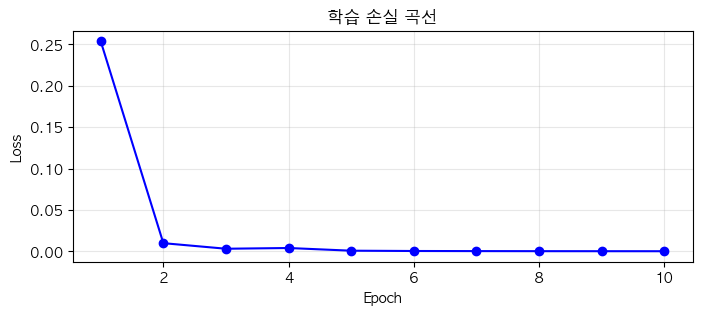

In [6]:
# 학습
NUM_EPOCHS = 10
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_history = []
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}')

# Loss 곡선
plt.figure(figsize=(8, 3))
plt.plot(range(1, NUM_EPOCHS+1), loss_history, 'b-o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('학습 손실 곡선')
plt.grid(alpha=0.3)
plt.show()

## STEP 5: 평가 - 정확도 급락 확인

이제 **학습 때 한 번도 보지 못한 021mil 결함 크기** 데이터로 평가합니다.

노트북 1에서는 ~100%였는데... 과연?

In [7]:
# 평가
model.eval()
with torch.no_grad():
    outputs = model(X_test_t.to(device))
    y_pred = outputs.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f'\n{"="*50}')
print(f'  일반화 테스트 정확도: {acc*100:.1f}%')
print(f'  (참고: 노트북 1에서는 ~100% 였음)')
print(f'{"="*50}')


  일반화 테스트 정확도: 59.3%
  (참고: 노트북 1에서는 ~100% 였음)


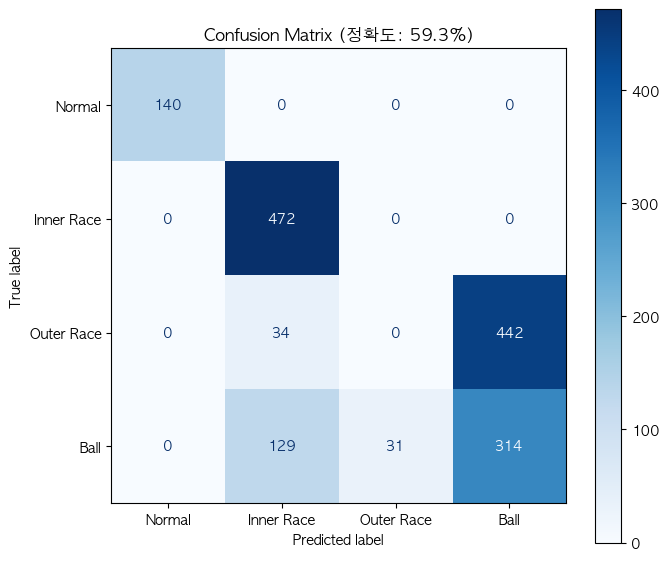

In [8]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    cmap='Blues',
    ax=ax
)
ax.set_title(f'Confusion Matrix (정확도: {acc*100:.1f}%)')
plt.tight_layout()
plt.show()

In [9]:
# 클래스별 성능 (Precision, Recall, F1-Score)
print('\n=== 클래스별 성능 (Classification Report) ===')
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))


=== 클래스별 성능 (Classification Report) ===
              precision    recall  f1-score   support

      Normal      1.000     1.000     1.000       140
  Inner Race      0.743     1.000     0.853       472
  Outer Race      0.000     0.000     0.000       476
        Ball      0.415     0.662     0.511       474

    accuracy                          0.593      1562
   macro avg      0.540     0.666     0.591      1562
weighted avg      0.440     0.593     0.502      1562



## STEP 6: 왜 모델이 헷갈렸을까? — 실제 파형으로 확인

Confusion Matrix에서 Outer Race와 Ball이 심하게 혼동되는 것을 확인했습니다.
정말로 021mil에서 두 결함의 FFT 스펙트럼이 비슷해지는지 눈으로 확인해봅시다.

**비교 방법:**
- 왼쪽: 학습에 사용한 **007mil** 파일들의 FFT 스펙트럼
- 오른쪽: 평가에 사용한 **021mil** 파일들의 FFT 스펙트럼

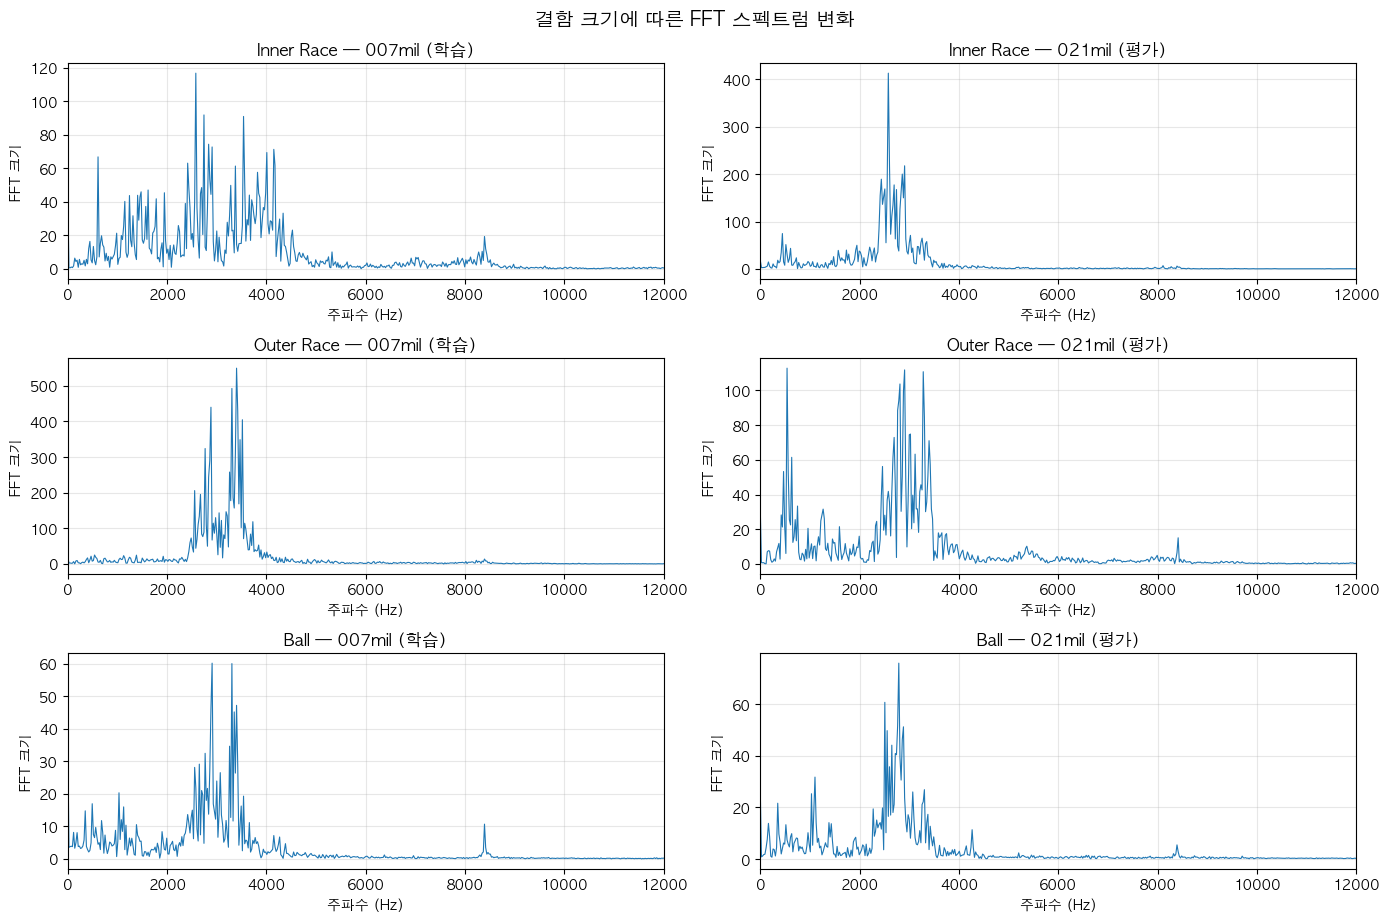

In [10]:
# 007mil(학습) vs 021mil(평가)의 FFT 스펙트럼을 클래스별로 비교
compare_files = {
    'Inner Race': ('IR007_1_110.mat', 'IR021_1_214.mat'),
    'Outer Race': ('OR007_6_1_136.mat', 'OR021_6_1_239.mat'),
    'Ball':       ('B007_1_123.mat', 'B021_1_227.mat'),
}

fs = 48000
fig, axes = plt.subplots(3, 2, figsize=(14, 9))

for row, (label, (f007, f021)) in enumerate(compare_files.items()):
    for col, (fname, size_label) in enumerate([(f007, '007mil (학습)'), (f021, '021mil (평가)')]):
        sig = get_de_signal(os.path.join(data_dir, fname))
        # 첫 번째 윈도우의 FFT
        window = sig[:WINDOW_SIZE]
        fft_vals = np.abs(np.fft.rfft(window))
        freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/fs)

        ax = axes[row, col]
        ax.plot(freqs, fft_vals, linewidth=0.8)
        ax.set_title(f'{label} — {size_label}')
        ax.set_xlabel('주파수 (Hz)')
        ax.set_ylabel('FFT 크기')
        ax.set_xlim(0, 12000)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('결함 크기에 따른 FFT 스펙트럼 변화', fontsize=14, y=1.02)
plt.show()

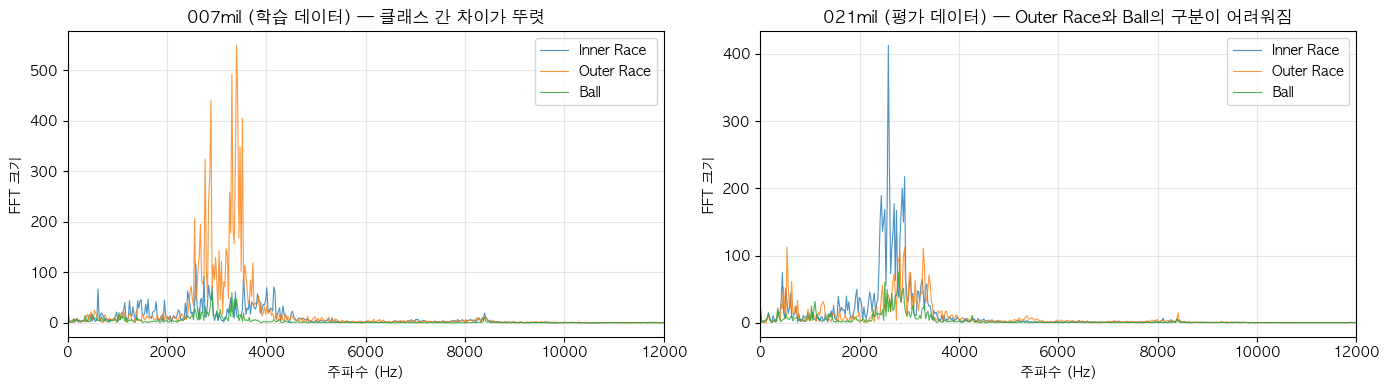

In [11]:
# 021mil 파일들의 FFT를 하나의 그래프에 겹쳐서 비교
# → Outer Race와 Ball이 얼마나 비슷한지 직접 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {'Inner Race': 'tab:blue', 'Outer Race': 'tab:orange', 'Ball': 'tab:green'}
test_021_files = {
    'Inner Race': 'IR021_1_214.mat',
    'Outer Race': 'OR021_6_1_239.mat',
    'Ball':       'B021_1_227.mat',
}

# 왼쪽: 007mil (학습 데이터) — 클래스 간 차이가 뚜렷
train_007_files = {
    'Inner Race': 'IR007_1_110.mat',
    'Outer Race': 'OR007_6_1_136.mat',
    'Ball':       'B007_1_123.mat',
}

for label, fname in train_007_files.items():
    sig = get_de_signal(os.path.join(data_dir, fname))
    fft_vals = np.abs(np.fft.rfft(sig[:WINDOW_SIZE]))
    freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/fs)
    axes[0].plot(freqs, fft_vals, label=label, color=colors[label], alpha=0.8, linewidth=0.8)

axes[0].set_title('007mil (학습 데이터) — 클래스 간 차이가 뚜렷')
axes[0].set_xlabel('주파수 (Hz)')
axes[0].set_ylabel('FFT 크기')
axes[0].set_xlim(0, 12000)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: 021mil (평가 데이터) — Outer Race와 Ball이 비슷해짐
for label, fname in test_021_files.items():
    sig = get_de_signal(os.path.join(data_dir, fname))
    fft_vals = np.abs(np.fft.rfft(sig[:WINDOW_SIZE]))
    freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/fs)
    axes[1].plot(freqs, fft_vals, label=label, color=colors[label], alpha=0.8, linewidth=0.8)

axes[1].set_title('021mil (평가 데이터) — Outer Race와 Ball의 구분이 어려워짐')
axes[1].set_xlabel('주파수 (Hz)')
axes[1].set_ylabel('FFT 크기')
axes[1].set_xlim(0, 12000)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 시각화 해석

위 그래프에서 확인할 수 있는 것:

**007mil (왼쪽, 학습 데이터)**
- Inner Race, Outer Race, Ball 각각의 FFT 스펙트럼이 **확연히 다른 형태**를 보임
- 모델이 이 차이를 학습해서 99% 정확도를 달성한 것

**021mil (오른쪽, 평가 데이터)**
- 결함 크기가 커지면서 각 클래스의 스펙트럼 형태가 **크게 달라짐**
- 특히 **Outer Race와 Ball의 스펙트럼이 비슷한 패턴**을 보이면서 모델이 혼동
- 모델 입장에서는 "학습 때 본 007mil 패턴"과 전혀 달라 보이므로 엉뚱한 클래스로 분류

> 결함이 커지면 충격 에너지가 증가하면서 여러 주파수 대역에 에너지가 퍼지게 되고,
> 원래 뚜렷했던 클래스 간 차이가 흐려집니다. 이것이 일반화 성능이 떨어지는 근본적인 이유입니다.

### Domain Shift (도메인 변화)

이런 현상을 **Domain Shift**라고 부릅니다:
- 학습 데이터의 분포(domain)와 실제 평가 데이터의 분포가 **다를 때** 발생
- 학습 조건 ≠ 운영 조건이면, 아무리 높은 정확도도 의미가 없음

### 핵심 교훈

> **"정확도 99%"라는 숫자만으로는 부족합니다.**
> **"어떤 조건에서 평가한 99%인가?"가 더 중요합니다.**

## STEP 7: 현장 적용 시사점

### 실제 설비에서도 이런 일이 벌어집니다

| 상황 | 설명 |
|------|------|
| 부하 변경 | 시멘트 밀의 투입량이 달라지면 진동 패턴 변화 |
| 계절 변화 | 온도/습도에 따라 윤활 상태가 달라짐 |
| 마모 진행 | 시간이 지나면서 결함이 점점 커짐 (007→014→021과 같은 상황) |
| 부품 교체 | 새 베어링은 기존과 미세하게 다른 특성 |

### AI 모델 도입 시 체크리스트

1. **학습 데이터의 조건**과 **실제 운영 조건**이 얼마나 비슷한지 확인
2. 다양한 조건의 데이터를 학습에 포함시키기
3. **주기적 재학습**: 운영 데이터가 쌓이면 모델을 업데이트
4. 정확도 숫자보다 **어떤 조건에서 측정한 정확도인지**가 중요

### 요약

| 평가 방법 | 정확도 | 의미 |
|-----------|--------|------|
| 동일 조건 분할 (노트북 1) | ~100% | 같은 조건의 데이터 → 쉬운 시험 |
| 결함 크기별 분할 (이번 노트북) | ~60% | 새로운 조건 → 현실적 성능 |

> **결론**: AI 모델의 성능은 "어떻게 평가했는가"에 따라 완전히 달라집니다.
> 현장 도입 전에는 반드시 **현실적인 조건**에서의 성능을 확인해야 합니다.